In [1]:
!pip install wfdb -q
print("done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.3 MB/s eta 0:00:00
done


In [2]:
import os, gc, warnings, ast
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from scipy.signal import butter, filtfilt, savgol_filter
from tqdm import tqdm
from tensorflow.keras.layers import (
    Input, Conv1D, Conv1DTranspose, BatchNormalization, Activation, Add,
    GlobalAveragePooling1D, Dense, Dropout, Multiply, Reshape,
    MaxPooling1D, Flatten, Concatenate, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import wfdb

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

BASE_PATH = "/kaggle/input/datasets/girijachowdary/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
DATA_ROOT = Path(BASE_PATH)
FS        = 500
SEQ_LEN   = 5000
CLASS_NAMES_3   = ['LVH', 'MI', 'NORMAL']
CLASS_NAMES_BIN = ['MI_LVH', 'NO_MI_LVH']

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))
print("DATA_ROOT exists:", DATA_ROOT.exists())

2026-06-22 05:19:21.114022: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782105561.302093      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782105561.359642      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782105561.814787      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782105561.814842      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782105561.814847      58 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
DATA_ROOT exists: True


In [3]:
df  = pd.read_csv(DATA_ROOT / "ptbxl_database.csv", index_col='ecg_id')
scp = pd.read_csv(DATA_ROOT / "scp_statements.csv", index_col=0)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
diagnostic_scp  = scp[scp['diagnostic'] == 1.0]

def get_superclass(codes):
    classes = set()
    for code in codes:
        if code in diagnostic_scp.index:
            sc = diagnostic_scp.loc[code, 'diagnostic_class']
            if pd.notna(sc):
                classes.add(sc)
    return classes

df['superclass'] = df['scp_codes'].apply(get_superclass)

def assign_3class(row):
    sc = row['superclass']
    has_mi  = 'MI'  in sc
    has_hyp = 'HYP' in sc
    if has_mi and not has_hyp:   return 'MI'      # MI only — 4651
    elif has_hyp and not has_mi: return 'LVH'     # LVH only — 1831
    elif sc == {'NORM'}:         return 'NORMAL'  # Normal — 9069
    return None   # MI+LVH excluded for now

def assign_binary(row):
    sc = row['superclass']
    has_mi  = 'MI'  in sc
    has_hyp = 'HYP' in sc
    if has_mi and has_hyp:  return 'MI_LVH'
    elif sc == {'NORM'}:    return 'NO_MI_LVH'
    return None

df['target_3']   = df.apply(assign_3class, axis=1)
df['target_bin'] = df.apply(assign_binary, axis=1)

df_3   = df[df['target_3'].notna()].copy()
df_bin = df[df['target_bin'].notna()].copy()

print("=== 3-CLASS ===")
print(df_3['target_3'].value_counts())
print("\n=== BINARY ===")
print(df_bin['target_bin'].value_counts())

=== 3-CLASS ===
target_3
NORMAL    9069
MI        4651
LVH       1831
Name: count, dtype: int64

=== BINARY ===
target_bin
NO_MI_LVH    9069
MI_LVH        818
Name: count, dtype: int64


In [4]:
train_meta_3   = df_3[~df_3['strat_fold'].isin([9,10])].copy()
val_meta_3     = df_3[ df_3['strat_fold'] == 9].copy()
test_meta_3    = df_3[ df_3['strat_fold'] == 10].copy()

train_meta_bin = df_bin[~df_bin['strat_fold'].isin([9,10])].copy()
val_meta_bin   = df_bin[ df_bin['strat_fold'] == 9].copy()
test_meta_bin  = df_bin[ df_bin['strat_fold'] == 10].copy()

print("=== 3-CLASS SPLITS ===")
print(f"Train: {len(train_meta_3)} | Val: {len(val_meta_3)} | Test: {len(test_meta_3)}")
print(train_meta_3['target_3'].value_counts())
print("\n=== BINARY SPLITS ===")
print(f"Train: {len(train_meta_bin)} | Val: {len(val_meta_bin)} | Test: {len(test_meta_bin)}")
print(train_meta_bin['target_bin'].value_counts())

=== 3-CLASS SPLITS ===
Train: 12441 | Val: 1544 | Test: 1566
target_3
NORMAL    7243
MI        3729
LVH       1469
Name: count, dtype: int64

=== BINARY SPLITS ===
Train: 7893 | Val: 1003 | Test: 991
target_bin
NO_MI_LVH    7243
MI_LVH        650
Name: count, dtype: int64


In [5]:
def bandpass_filter(signal, lowcut=0.5, highcut=40):
    nyq  = FS / 2
    low  = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, signal)

def preprocess_ecg(ecg):
    processed = np.zeros((SEQ_LEN, 12), dtype=np.float32)
    ecg = ecg[:SEQ_LEN] if len(ecg) >= SEQ_LEN else np.pad(
        ecg, ((0, SEQ_LEN - len(ecg)), (0, 0))
    )
    for lead in range(12):
        sig = ecg[:, lead].astype(np.float64)
        sig = savgol_filter(sig, 11, 3)
        sig = bandpass_filter(sig)
        sig = (sig - np.mean(sig)) / (np.std(sig) + 1e-8)
        processed[:, lead] = sig.astype(np.float32)
    return processed

def load_and_preprocess(meta_df, desc="Loading"):
    signals = []
    for fname in tqdm(meta_df['filename_hr'], desc=desc):
        path = os.path.join(BASE_PATH, fname)
        try:
            signal, _ = wfdb.rdsamp(path)
            signals.append(preprocess_ecg(signal))
        except:
            signals.append(np.zeros((SEQ_LEN, 12), dtype=np.float32))
    return np.array(signals, dtype=np.float32)

print("Preprocessing functions ready.")

Preprocessing functions ready.


In [6]:
print("Loading 3-Class ECGs...")
X_train_3 = load_and_preprocess(train_meta_3, "3-Class Train")
X_val_3   = load_and_preprocess(val_meta_3,   "3-Class Val")
X_test_3  = load_and_preprocess(test_meta_3,  "3-Class Test")

print(f"\nX_train_3 : {X_train_3.shape}")
print(f"X_val_3   : {X_val_3.shape}")
print(f"X_test_3  : {X_test_3.shape}")

Loading 3-Class ECGs...


3-Class Test: 100%|██████████| 1566/1566 [00:44<00:00, 34.94it/s]



X_train_3 : (12441, 5000, 12)
X_val_3   : (1544, 5000, 12)
X_test_3  : (1566, 5000, 12)


In [7]:
print("Loading Binary ECGs...")
X_train_b = load_and_preprocess(train_meta_bin, "Binary Train")
X_val_b   = load_and_preprocess(val_meta_bin,   "Binary Val")
X_test_b  = load_and_preprocess(test_meta_bin,  "Binary Test")

print(f"\nX_train_b : {X_train_b.shape}")
print(f"X_val_b   : {X_val_b.shape}")
print(f"X_test_b  : {X_test_b.shape}")

Loading Binary ECGs...


Binary Test: 100%|██████████| 991/991 [00:21<00:00, 45.82it/s]



X_train_b : (7893, 5000, 12)
X_val_b   : (1003, 5000, 12)
X_test_b  : (991, 5000, 12)


In [8]:
le3 = LabelEncoder()
le3.fit(['LVH', 'MI', 'NORMAL'])
CLASS_NAMES_3 = list(le3.classes_)  # ['LVH', 'MI', 'NORMAL']

y_train_3 = le3.transform(train_meta_3['target_3'].values)
y_val_3   = le3.transform(val_meta_3['target_3'].values)
y_test_3  = le3.transform(test_meta_3['target_3'].values)

le_bin = LabelEncoder()
le_bin.fit(['MI_LVH', 'NO_MI_LVH'])
CLASS_NAMES_BIN = list(le_bin.classes_)

y_train_bin = le_bin.transform(train_meta_bin['target_bin'].values)
y_val_bin   = le_bin.transform(val_meta_bin['target_bin'].values)
y_test_bin  = le_bin.transform(test_meta_bin['target_bin'].values)

print("3-Class labels:", CLASS_NAMES_3)
print("Train dist:", dict(zip(CLASS_NAMES_3, np.bincount(y_train_3))))
print("\nBinary labels:", CLASS_NAMES_BIN)
print("Train dist:", dict(zip(CLASS_NAMES_BIN, np.bincount(y_train_bin))))

3-Class labels: [np.str_('LVH'), np.str_('MI'), np.str_('NORMAL')]
Train dist: {np.str_('LVH'): np.int64(1469), np.str_('MI'): np.int64(3729), np.str_('NORMAL'): np.int64(7243)}

Binary labels: [np.str_('MI_LVH'), np.str_('NO_MI_LVH')]
Train dist: {np.str_('MI_LVH'): np.int64(650), np.str_('NO_MI_LVH'): np.int64(7243)}


In [9]:
df_meta = df.copy()
df_meta['age']    = df_meta['age'].fillna(df_meta['age'].median())
df_meta['sex']    = df_meta['sex'].fillna(0)
df_meta['height'] = df_meta['height'].fillna(df_meta['height'].median())
df_meta['weight'] = df_meta['weight'].fillna(df_meta['weight'].median())
axis_map = {'NORM': 0, 'LAD': 1, 'RAD': 2, 'MID': 3, 'SINUS': 4}
df_meta['heart_axis'] = df_meta['heart_axis'].map(axis_map).fillna(0)
meta_cols = ['age', 'sex', 'height', 'weight', 'heart_axis']
scaler = StandardScaler()
df_meta[meta_cols] = scaler.fit_transform(df_meta[meta_cols])

meta_train_3   = df_meta.loc[train_meta_3.index][meta_cols].values.astype(np.float32)
meta_val_3     = df_meta.loc[val_meta_3.index][meta_cols].values.astype(np.float32)
meta_test_3    = df_meta.loc[test_meta_3.index][meta_cols].values.astype(np.float32)
meta_train_bin = df_meta.loc[train_meta_bin.index][meta_cols].values.astype(np.float32)
meta_val_bin   = df_meta.loc[val_meta_bin.index][meta_cols].values.astype(np.float32)
meta_test_bin  = df_meta.loc[test_meta_bin.index][meta_cols].values.astype(np.float32)

print("Metadata shapes:")
print(f"3-class  train: {meta_train_3.shape} | val: {meta_val_3.shape} | test: {meta_test_3.shape}")
print(f"Binary   train: {meta_train_bin.shape} | val: {meta_val_bin.shape} | test: {meta_test_bin.shape}")

Metadata shapes:
3-class  train: (12441, 5) | val: (1544, 5) | test: (1566, 5)
Binary   train: (7893, 5) | val: (1003, 5) | test: (991, 5)


In [10]:
np.save('/kaggle/working/X_train_3.npy',   X_train_3)
np.save('/kaggle/working/X_val_3.npy',     X_val_3)
np.save('/kaggle/working/X_test_3.npy',    X_test_3)
np.save('/kaggle/working/y_train_3.npy',   y_train_3)
np.save('/kaggle/working/y_val_3.npy',     y_val_3)
np.save('/kaggle/working/y_test_3.npy',    y_test_3)
np.save('/kaggle/working/X_train_b.npy',   X_train_b)
np.save('/kaggle/working/X_val_b.npy',     X_val_b)
np.save('/kaggle/working/X_test_b.npy',    X_test_b)
np.save('/kaggle/working/y_train_bin.npy', y_train_bin)
np.save('/kaggle/working/y_val_bin.npy',   y_val_bin)
np.save('/kaggle/working/y_test_bin.npy',  y_test_bin)
print("All data saved.")

All data saved.


In [11]:
def build_autoencoder(seq_len=5000, n_leads=12, latent_dim=128):
    # Encoder
    enc_input = Input(shape=(seq_len, n_leads), name='enc_input')
    x = Conv1D(32, 25, strides=4, padding='same', use_bias=False)(enc_input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv1D(64, 15, strides=4, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv1D(128, 9, strides=4, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    enc_flat   = Flatten()(x)
    latent_out = Dense(latent_dim, activation='relu', name='latent')(enc_flat)

    # Decoder
    x = Dense(79 * 128, activation='relu')(latent_out)
    x = Reshape((79, 128))(x)
    x = Conv1DTranspose(128, 9, strides=4, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv1DTranspose(64, 15, strides=4, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv1DTranspose(32, 25, strides=4, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    dec_out = Conv1D(n_leads, 1, padding='same', activation='linear')(x)
    dec_out = Lambda(lambda t: t[:, :seq_len, :], name='crop')(dec_out)

    autoencoder = Model(enc_input, dec_out, name='autoencoder')
    encoder     = Model(enc_input, latent_out, name='encoder')
    return autoencoder, encoder

print("Autoencoder builder ready.")

Autoencoder builder ready.


In [12]:
lvh_idx    = np.where(y_train_3 == 0)[0]
mi_idx     = np.where(y_train_3 == 1)[0]
normal_idx = np.where(y_train_3 == 2)[0]

X_lvh    = X_train_3[lvh_idx]
X_mi     = X_train_3[mi_idx]
X_normal = X_train_3[normal_idx]

print(f"LVH    : {X_lvh.shape}  ← minority 1")
print(f"MI     : {X_mi.shape}   ← minority 2")
print(f"Normal : {X_normal.shape}")

# Autoencoder for LVH
print("\n--- Training LVH autoencoder ---")
ae_lvh, enc_lvh = build_autoencoder(latent_dim=128)
ae_lvh.compile(optimizer=AdamW(learning_rate=1e-3), loss='mse')
ae_lvh.fit(
    X_lvh, X_lvh,
    epochs=30, batch_size=16, validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

# Autoencoder for MI
print("\n--- Training MI autoencoder ---")
ae_mi, enc_mi = build_autoencoder(latent_dim=128)
ae_mi.compile(optimizer=AdamW(learning_rate=1e-3), loss='mse')
ae_mi.fit(
    X_mi, X_mi,
    epochs=30, batch_size=16, validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

print("\nBoth autoencoders trained.")

LVH    : (1469, 5000, 12)  ← minority 1
MI     : (3729, 5000, 12)   ← minority 2
Normal : (7243, 5000, 12)

--- Training LVH autoencoder ---


I0000 00:00:1782106249.153083      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782106249.159028      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/30


I0000 00:00:1782106256.576277     133 service.cc:152] XLA service 0x7dd1c0001f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782106256.576341     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782106256.576348     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782106257.426583     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


10/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.4674

I0000 00:00:1782106262.403799     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


83/83 ━━━━━━━━━━━━━━━━━━━━ 18s 95ms/step - loss: 1.0404 - val_loss: 1.0012
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0001 - val_loss: 1.0002
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0001 - val_loss: 1.0000
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 5/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 6/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 7/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 8/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 9/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 10/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 11/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 12/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.0000 - val_

In [13]:
def generate_synthetic_ecgs(autoencoder, encoder, real_signals, n_generate, noise_std=0.2):
    print(f"  Encoding {len(real_signals)} real signals...")
    latents       = encoder.predict(real_signals, batch_size=16, verbose=0)
    chosen_idx    = np.random.choice(len(latents), n_generate, replace=True)
    src_signals   = real_signals[chosen_idx]
    reconstructed = autoencoder.predict(src_signals, batch_size=16, verbose=0)
    residual      = np.random.normal(0, 0.03, reconstructed.shape).astype(np.float32)
    return (reconstructed + residual).astype(np.float32)

TARGET     = 3500
n_lvh_need = TARGET - len(X_lvh)
n_mi_need  = max(0, TARGET - len(X_mi))

print(f"Real LVH : {len(X_lvh)} | Need to generate : {n_lvh_need}")
print(f"Real MI  : {len(X_mi)}  | Need to generate : {n_mi_need}")

print("\nGenerating synthetic LVH ECGs...")
X_lvh_syn = generate_synthetic_ecgs(
    ae_lvh, enc_lvh, X_lvh, n_lvh_need, noise_std=0.2
)

if n_mi_need > 0:
    print("\nGenerating synthetic MI ECGs...")
    X_mi_syn = generate_synthetic_ecgs(
        ae_mi, enc_mi, X_mi, n_mi_need, noise_std=0.2
    )
else:
    X_mi_syn = None

print(f"\nSynthetic LVH shape : {X_lvh_syn.shape}")
if X_mi_syn is not None:
    print(f"Synthetic MI shape  : {X_mi_syn.shape}")
else:
    print("MI has enough samples — no augmentation needed")

Real LVH : 1469 | Need to generate : 2031
Real MI  : 3729  | Need to generate : 0

Generating synthetic LVH ECGs...
  Encoding 1469 real signals...

Synthetic LVH shape : (2031, 5000, 12)
MI has enough samples — no augmentation needed


In [14]:
# LVH — real + synthetic
X_lvh_all  = np.concatenate([X_lvh, X_lvh_syn])
y_lvh_all  = np.zeros(len(X_lvh_all), dtype=np.int32)

# MI — real + synthetic if needed, else downsample
if X_mi_syn is not None:
    X_mi_all = np.concatenate([X_mi, X_mi_syn])[:TARGET]
else:
    mi_chosen = np.random.choice(mi_idx, TARGET, replace=False)
    X_mi_all  = X_train_3[mi_chosen]
y_mi_all = np.ones(len(X_mi_all), dtype=np.int32)

# Normal — downsample
norm_chosen = np.random.choice(normal_idx, TARGET, replace=False)
X_norm_all  = X_train_3[norm_chosen]
y_norm_all  = np.full(len(X_norm_all), 2, dtype=np.int32)

# Metadata
meta_lvh_real = meta_train_3[lvh_idx]
meta_lvh_syn  = meta_train_3[
    lvh_idx[np.random.choice(len(lvh_idx), n_lvh_need, replace=True)]
] + np.random.normal(0, 0.01, (n_lvh_need, 5)).astype(np.float32)
meta_lvh_all  = np.concatenate([meta_lvh_real, meta_lvh_syn])

if X_mi_syn is not None:
    meta_mi_syn = meta_train_3[
        mi_idx[np.random.choice(len(mi_idx), n_mi_need, replace=True)]
    ] + np.random.normal(0, 0.01, (n_mi_need, 5)).astype(np.float32)
    meta_mi_all = np.concatenate([meta_train_3[mi_idx], meta_mi_syn])[:TARGET]
else:
    meta_mi_all = meta_train_3[mi_chosen]

meta_norm_all = meta_train_3[norm_chosen]

# Combine
X_train_aug    = np.concatenate([X_lvh_all,    X_mi_all,    X_norm_all])
y_train_aug    = np.concatenate([y_lvh_all,    y_mi_all,    y_norm_all])
meta_train_aug = np.concatenate([meta_lvh_all, meta_mi_all, meta_norm_all])

shuf = np.random.permutation(len(X_train_aug))
X_train_aug    = X_train_aug[shuf]
y_train_aug    = y_train_aug[shuf]
meta_train_aug = meta_train_aug[shuf]

print("=== 3-CLASS AUGMENTED TRAINING SET ===")
print("Distribution:", {CLASS_NAMES_3[k]: v for k,v in sorted(Counter(y_train_aug).items())})
print("ECG shape   :", X_train_aug.shape)
print("Meta shape  :", meta_train_aug.shape)

=== 3-CLASS AUGMENTED TRAINING SET ===
Distribution: {np.str_('LVH'): 3500, np.str_('MI'): 3500, np.str_('NORMAL'): 3500}
ECG shape   : (10500, 5000, 12)
Meta shape  : (10500, 5)


In [15]:
w_aug  = compute_class_weight('balanced', classes=np.unique(y_train_aug), y=y_train_aug)
cw_aug = {i: w for i, w in enumerate(w_aug)}
print("Class weights:", {CLASS_NAMES_3[k]: round(v,3) for k,v in cw_aug.items()})

Class weights: {np.str_('LVH'): np.float64(1.0), np.str_('MI'): np.float64(1.0), np.str_('NORMAL'): np.float64(1.0)}


In [16]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def se_block(x, ratio=8):
    filters = x.shape[-1]
    se = GlobalAveragePooling1D()(x)
    se = Reshape((1, filters))(se)
    se = Dense(max(1, filters//ratio), activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    return Multiply()([x, se])

def res_block(x, filters, kernel_size=7, downsample=False):
    stride = 2 if downsample else 1
    out = Conv1D(filters, kernel_size, strides=stride, padding='same', use_bias=False)(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(0.2)(out)
    out = Conv1D(filters, kernel_size, padding='same', use_bias=False)(out)
    out = BatchNormalization()(out)
    out = se_block(out)
    if downsample or x.shape[-1] != filters:
        x = Conv1D(filters, 1, strides=stride, padding='same', use_bias=False)(x)
        x = BatchNormalization()(x)
    return Activation('relu')(Add()([out, x]))

def build_fusion_model(n_classes=3, n_meta=5):
    # ECG branch
    ecg_input = Input(shape=(SEQ_LEN, 12), name='ecg_input')
    x = Conv1D(64, 25, strides=4, padding='same', use_bias=False)(ecg_input)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(2, padding='same')(x)
    x = res_block(x, 64,  kernel_size=7)
    x = res_block(x, 128, kernel_size=5, downsample=True)
    x = res_block(x, 128, kernel_size=5)
    x = res_block(x, 256, kernel_size=3, downsample=True)
    x = res_block(x, 256, kernel_size=3)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
    x = Dropout(0.4)(x)

    # Metadata branch
    meta_input = Input(shape=(n_meta,), name='meta_input')
    m = Dense(32, activation='relu')(meta_input)
    m = Dropout(0.3)(m)
    m = Dense(16, activation='relu')(m)

    # Fusion
    fused = Concatenate()([x, m])
    fused = Dense(64, activation='relu')(fused)
    fused = Dropout(0.3)(fused)

    if n_classes == 2:
        outputs = Dense(1, activation='sigmoid', dtype='float32')(fused)
    else:
        outputs = Dense(n_classes, activation='softmax', dtype='float32')(fused)

    return Model(inputs=[ecg_input, meta_input], outputs=outputs)

model_3 = build_fusion_model(n_classes=3, n_meta=5)
model_3.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(f"3-Class model params: {model_3.count_params():,}")
print("Ready.")

3-Class model params: 1,186,811
Ready.


In [17]:
callbacks_3 = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_3class.keras',
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("=== TRAINING 3-CLASS MODEL (Autoencoder-augmented) ===")
history_3 = model_3.fit(
    [X_train_aug, meta_train_aug],
    y_train_aug,
    validation_data=([X_val_3, meta_val_3], y_val_3),
    epochs=80,
    batch_size=32,
    class_weight=cw_aug,
    callbacks=callbacks_3,
    verbose=1
)

=== TRAINING 3-CLASS MODEL (Autoencoder-augmented) ===
Epoch 1/80
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7360 - loss: 0.7745
Epoch 1: val_loss improved from None to 0.89775, saving model to /kaggle/working/best_model_3class.keras

Epoch 1: finished saving model to /kaggle/working/best_model_3class.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 63s 91ms/step - accuracy: 0.7772 - loss: 0.6777 - val_accuracy: 0.7902 - val_loss: 0.8977 - learning_rate: 0.0010
Epoch 2/80
328/329 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8100 - loss: 0.5622
Epoch 2: val_loss improved from 0.89775 to 0.50065, saving model to /kaggle/working/best_model_3class.keras

Epoch 2: finished saving model to /kaggle/working/best_model_3class.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8179 - loss: 0.5404 - val_accuracy: 0.8290 - val_loss: 0.5007 - learning_rate: 0.0010
Epoch 3/80
325/329 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8248 - loss: 0.5038
Epoch 3: val_loss did not improve fr

=== 3-CLASS RESULTS ===
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step
              precision    recall  f1-score   support

         LVH       0.75      0.46      0.57       183
          MI       0.78      0.81      0.79       471
      NORMAL       0.87      0.92      0.90       912

    accuracy                           0.83      1566
   macro avg       0.80      0.73      0.75      1566
weighted avg       0.83      0.83      0.83      1566

Macro F1 : 0.7532
Accuracy : 0.834


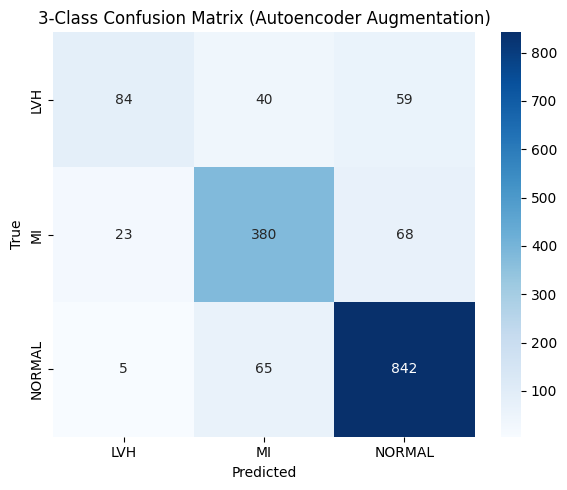

In [18]:
print("=== 3-CLASS RESULTS ===")
y_pred_3 = np.argmax(
    model_3.predict([X_test_3, meta_test_3], batch_size=32),
    axis=1
)
print(classification_report(y_test_3, y_pred_3, target_names=CLASS_NAMES_3))
print("Macro F1 :", round(f1_score(y_test_3, y_pred_3, average='macro'), 4))
print("Accuracy :", round(np.mean(y_pred_3 == y_test_3), 4))

cm = confusion_matrix(y_test_3, y_pred_3)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3)
plt.title('3-Class Confusion Matrix (Autoencoder Augmentation)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/cm_3class_ae.png', dpi=150)
plt.show()

In [19]:
# Binary: MI_LVH(0) vs NO_MI_LVH(1)
# Get binary training signals
pos_bin_idx = np.where(y_train_bin == 0)[0]   # MI_LVH
neg_bin_idx = np.where(y_train_bin == 1)[0]   # NO_MI_LVH

X_pos_bin = X_train_b[pos_bin_idx]   # MI+LVH ECGs
X_neg_bin = X_train_b[neg_bin_idx]   # Normal ECGs

print(f"Binary positive (MI_LVH)  : {X_pos_bin.shape}")
print(f"Binary negative (NO_MI_LVH): {X_neg_bin.shape}")

TARGET_BIN = 3500

# Train binary autoencoder on MI+LVH
print("\n--- Training binary MI+LVH autoencoder ---")
ae_bin, enc_bin = build_autoencoder(latent_dim=128)
ae_bin.compile(optimizer=AdamW(learning_rate=1e-3), loss='mse')
ae_bin.fit(
    X_pos_bin, X_pos_bin,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

# Generate synthetic MI+LVH for binary task
n_bin_need = TARGET_BIN - len(X_pos_bin)
print(f"\nGenerating {n_bin_need} synthetic MI+LVH for binary task...")
X_pos_syn = generate_synthetic_ecgs(
    ae_bin, enc_bin, X_pos_bin, n_bin_need, noise_std=0.2
)

# Combine positive
X_pos_all = np.concatenate([X_pos_bin, X_pos_syn])
y_pos_all = np.zeros(len(X_pos_all), dtype=np.int32)

# Downsample negative
neg_chosen  = np.random.choice(neg_bin_idx, TARGET_BIN, replace=False)
X_neg_all   = X_train_b[neg_chosen]
y_neg_all   = np.ones(TARGET_BIN, dtype=np.int32)

# Metadata
meta_pos_real = meta_train_bin[pos_bin_idx]
meta_pos_syn  = meta_train_bin[
    pos_bin_idx[np.random.choice(len(pos_bin_idx), n_bin_need, replace=True)]
] + np.random.normal(0, 0.01, (n_bin_need, 5)).astype(np.float32)
meta_pos_all  = np.concatenate([meta_pos_real, meta_pos_syn])
meta_neg_all  = meta_train_bin[neg_chosen]

# Final binary training set
X_train_bf    = np.concatenate([X_pos_all,   X_neg_all])
y_train_bf    = np.concatenate([y_pos_all,   y_neg_all])
meta_train_bf = np.concatenate([meta_pos_all, meta_neg_all])

shuf = np.random.permutation(len(X_train_bf))
X_train_bf    = X_train_bf[shuf]
y_train_bf    = y_train_bf[shuf]
meta_train_bf = meta_train_bf[shuf]

print("\n=== BINARY AUGMENTED TRAINING SET ===")
print("Distribution:", Counter(y_train_bf))
print("Shape:", X_train_bf.shape)

Binary positive (MI_LVH)  : (650, 5000, 12)
Binary negative (NO_MI_LVH): (7243, 5000, 12)

--- Training binary MI+LVH autoencoder ---
Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 294ms/step - loss: 1.0942 - val_loss: 1.0042
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0004 - val_loss: 1.0006
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0001 - val_loss: 1.0003
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0001 - val_loss: 1.0001
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0001 - val_loss: 1.0001
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 9/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 10/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0000 - val_loss: 1.0000
Epoch 11/30
3

In [20]:
wb   = compute_class_weight('balanced', classes=np.unique(y_train_bf), y=y_train_bf)
cw_b = {i: w for i, w in enumerate(wb)}
print({CLASS_NAMES_BIN[k]: round(v,3) for k,v in cw_b.items()})

{np.str_('MI_LVH'): np.float64(1.0), np.str_('NO_MI_LVH'): np.float64(1.0)}


In [21]:
model_b = build_fusion_model(n_classes=2, n_meta=5)
model_b.compile(
    optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-2),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
print(f"Binary model params: {model_b.count_params():,}")

callbacks_b = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_binary.keras',
                    monitor='val_loss', save_best_only=True, verbose=1)
]

print("=== TRAINING BINARY MODEL ===")
history_b = model_b.fit(
    [X_train_bf, meta_train_bf],
    y_train_bf,
    validation_data=([X_val_b, meta_val_bin], y_val_bin),
    epochs=80,
    batch_size=32,
    class_weight=cw_b,
    callbacks=callbacks_b,
    verbose=1
)

Binary model params: 1,186,681
=== TRAINING BINARY MODEL ===
Epoch 1/80
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9370 - auc: 0.9774 - loss: 0.2878
Epoch 1: val_loss improved from None to 0.14677, saving model to /kaggle/working/best_model_binary.keras

Epoch 1: finished saving model to /kaggle/working/best_model_binary.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 58s 134ms/step - accuracy: 0.9630 - auc: 0.9896 - loss: 0.2136 - val_accuracy: 0.9801 - val_auc: 0.9856 - val_loss: 0.1468 - learning_rate: 0.0010
Epoch 2/80
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9778 - auc: 0.9954 - loss: 0.1318
Epoch 2: val_loss improved from 0.14677 to 0.11126, saving model to /kaggle/working/best_model_binary.keras

Epoch 2: finished saving model to /kaggle/working/best_model_binary.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9774 - auc: 0.9956 - loss: 0.1228 - val_accuracy: 0.9771 - val_auc: 0.9897 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 3/80
215/219 ━━━━

=== BINARY RESULTS ===
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step
Best threshold: 0.42
              precision    recall  f1-score   support

      MI_LVH       0.94      0.91      0.92        79
   NO_MI_LVH       0.99      0.99      0.99       912

    accuracy                           0.99       991
   macro avg       0.96      0.95      0.96       991
weighted avg       0.99      0.99      0.99       991

Macro F1 : 0.9583
Accuracy : 0.9879


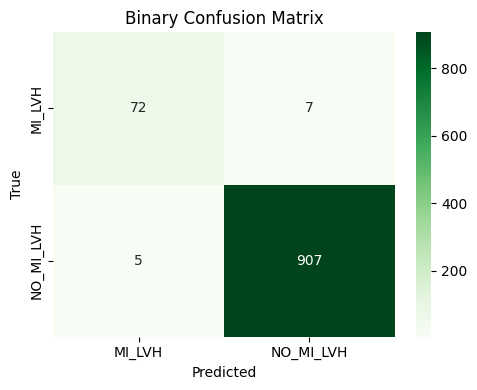

In [22]:
print("=== BINARY RESULTS ===")
y_prob_b = model_b.predict([X_test_b, meta_test_bin], batch_size=32).flatten()

best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.1, 0.9, 0.02):
    y_pred = (y_prob_b > thresh).astype(int)
    f1 = f1_score(y_test_bin, y_pred, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

y_final_b = (y_prob_b > best_thresh).astype(int)
print(f"Best threshold: {best_thresh:.2f}")
print(classification_report(y_test_bin, y_final_b, target_names=CLASS_NAMES_BIN))
print("Macro F1 :", round(f1_score(y_test_bin, y_final_b, average='macro'), 4))
print("Accuracy :", round(np.mean(y_final_b == y_test_bin), 4))

cm = confusion_matrix(y_test_bin, y_final_b)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES_BIN, yticklabels=CLASS_NAMES_BIN)
plt.title('Binary Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/cm_binary_ae.png', dpi=150)
plt.show()

In [23]:
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Model':<35} {'Macro F1':<12} {'Accuracy'}")
print("-"*60)
print(f"{'3-Class (AE augmentation)':<35} {round(f1_score(y_test_3, y_pred_3, average='macro'),3):<12} {round(np.mean(y_pred_3==y_test_3)*100,1)}%")
print(f"{'Binary MI&LVH detection':<35} {round(f1_score(y_test_bin, y_final_b, average='macro'),3):<12} {round(np.mean(y_final_b==y_test_bin)*100,1)}%")
print("="*60)

FINAL RESULTS SUMMARY
Model                               Macro F1     Accuracy
------------------------------------------------------------
3-Class (AE augmentation)           0.753        83.4%
Binary MI&LVH detection             0.958        98.8%


In [24]:
import os, warnings, ast
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_PATH  = "/kaggle/input/datasets/girijachowdary/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
DATA_ROOT  = Path(BASE_PATH)
FS         = 500
SEQ_LEN    = 5000
CLASS_NAMES_3   = ['LVH', 'MI', 'NORMAL']
CLASS_NAMES_BIN = ['MI_LVH', 'NO_MI_LVH']
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
LEAD_IDX   = {name: i for i, name in enumerate(LEAD_NAMES)}
time_axis  = np.arange(SEQ_LEN) / FS

# Load numpy data
X_test_3    = np.load('/kaggle/working/X_test_3.npy')
X_test_b    = np.load('/kaggle/working/X_test_b.npy')
y_test_3    = np.load('/kaggle/working/y_test_3.npy')
y_test_bin  = np.load('/kaggle/working/y_test_bin.npy')
X_train_3   = np.load('/kaggle/working/X_train_3.npy')
X_train_b   = np.load('/kaggle/working/X_train_b.npy')

print("Data loaded.")
print(f"X_test_3 : {X_test_3.shape}")
print(f"X_test_b : {X_test_b.shape}")

Data loaded.
X_test_3 : (1566, 5000, 12)
X_test_b : (991, 5000, 12)


In [25]:
df  = pd.read_csv(DATA_ROOT / "ptbxl_database.csv", index_col='ecg_id')
scp = pd.read_csv(DATA_ROOT / "scp_statements.csv", index_col=0)
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
diagnostic_scp  = scp[scp['diagnostic'] == 1.0]

def get_superclass(codes):
    classes = set()
    for code in codes:
        if code in diagnostic_scp.index:
            sc = diagnostic_scp.loc[code, 'diagnostic_class']
            if pd.notna(sc):
                classes.add(sc)
    return classes

df['superclass'] = df['scp_codes'].apply(get_superclass)

def assign_3class(row):
    sc = row['superclass']
    has_mi  = 'MI'  in sc
    has_hyp = 'HYP' in sc
    if has_mi and not has_hyp:   return 'MI'
    elif has_hyp and not has_mi: return 'LVH'
    elif sc == {'NORM'}:         return 'NORMAL'
    return None

def assign_binary(row):
    sc = row['superclass']
    has_mi  = 'MI'  in sc
    has_hyp = 'HYP' in sc
    if has_mi and has_hyp:  return 'MI_LVH'
    elif sc == {'NORM'}:    return 'NO_MI_LVH'
    return None

df['target_3']   = df.apply(assign_3class, axis=1)
df['target_bin'] = df.apply(assign_binary, axis=1)

df_3   = df[df['target_3'].notna()].copy()
df_bin = df[df['target_bin'].notna()].copy()

train_meta_3   = df_3[~df_3['strat_fold'].isin([9,10])].copy()
test_meta_3    = df_3[ df_3['strat_fold'] == 10].copy()
train_meta_bin = df_bin[~df_bin['strat_fold'].isin([9,10])].copy()
test_meta_bin  = df_bin[ df_bin['strat_fold'] == 10].copy()

df_meta = df.copy()
df_meta['age']    = df_meta['age'].fillna(df_meta['age'].median())
df_meta['sex']    = df_meta['sex'].fillna(0)
df_meta['height'] = df_meta['height'].fillna(df_meta['height'].median())
df_meta['weight'] = df_meta['weight'].fillna(df_meta['weight'].median())
axis_map = {'NORM': 0, 'LAD': 1, 'RAD': 2, 'MID': 3, 'SINUS': 4}
df_meta['heart_axis'] = df_meta['heart_axis'].map(axis_map).fillna(0)
meta_cols = ['age', 'sex', 'height', 'weight', 'heart_axis']
scaler = StandardScaler()
df_meta[meta_cols] = scaler.fit_transform(df_meta[meta_cols])

meta_train_3   = df_meta.loc[train_meta_3.index][meta_cols].values.astype(np.float32)
meta_test_3    = df_meta.loc[test_meta_3.index][meta_cols].values.astype(np.float32)
meta_train_bin = df_meta.loc[train_meta_bin.index][meta_cols].values.astype(np.float32)
meta_test_bin  = df_meta.loc[test_meta_bin.index][meta_cols].values.astype(np.float32)

print("Metadata ready.")
print(f"meta_test_3  : {meta_test_3.shape}")
print(f"meta_test_bin: {meta_test_bin.shape}")

Metadata ready.
meta_test_3  : (1566, 5)
meta_test_bin: (991, 5)


In [26]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

model_fusion_3 = tf.keras.models.load_model('/kaggle/working/best_model_3class.keras')
model_fusion_b = tf.keras.models.load_model('/kaggle/working/best_model_binary.keras')

print("Models loaded.")

# 3-class predictions
y_pred_prob_3 = model_fusion_3.predict([X_test_3, meta_test_3], batch_size=32)
y_pred_3      = np.argmax(y_pred_prob_3, axis=1)

# Binary predictions with threshold tuning
y_prob_b = model_fusion_b.predict([X_test_b, meta_test_bin], batch_size=32).flatten()
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.1, 0.9, 0.02):
    y_pred = (y_prob_b > thresh).astype(int)
    f1 = f1_score(y_test_bin, y_pred, average='macro')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh
y_final_b = (y_prob_b > best_thresh).astype(int)

print(f"\n3-Class  Macro F1: {round(f1_score(y_test_3, y_pred_3, average='macro'), 4)}")
print(f"3-Class  Accuracy: {round(np.mean(y_pred_3 == y_test_3)*100, 1)}%")
print(f"Binary   Macro F1: {round(f1_score(y_test_bin, y_final_b, average='macro'), 4)}")
print(f"Binary   Accuracy: {round(np.mean(y_final_b == y_test_bin)*100, 1)}%")

Models loaded.
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step

3-Class  Macro F1: 0.7532
3-Class  Accuracy: 83.4%
Binary   Macro F1: 0.9583
Binary   Accuracy: 98.8%


In [27]:
def grad_cam_ecg(model, ecg_input, meta_input, class_idx=None):
    conv_layers = [l.name for l in model.layers
                   if 'conv1d' in l.name
                   and 'conv1d_transpose' not in l.name]
    last_conv = conv_layers[-1]

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv).output, model.output]
    )
    ecg_t  = tf.cast(tf.expand_dims(ecg_input,  0), tf.float32)
    meta_t = tf.cast(tf.expand_dims(meta_input, 0), tf.float32)

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model([ecg_t, meta_t])
        is_binary = (preds.shape[-1] == 1)
        if is_binary:
            loss       = preds[:, 0]
            confidence = float(preds[0][0])
            class_idx  = 0
        else:
            if class_idx is None:
                class_idx = int(tf.argmax(preds[0]).numpy())
            loss       = preds[:, class_idx]
            confidence = float(preds[0][class_idx])

    grads        = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=1)[0]
    conv_out     = conv_out[0]
    heatmap      = tf.reduce_sum(tf.multiply(pooled_grads, conv_out), axis=-1)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)
    hup = np.interp(
        np.linspace(0, len(heatmap.numpy())-1, SEQ_LEN),
        np.arange(len(heatmap.numpy())),
        heatmap.numpy()
    )
    return hup, confidence

print("Grad-CAM function ready.")

Grad-CAM function ready.


In [28]:
# MI only (3-class, class=1)
mi_idx  = np.where((y_test_3 == 1) & (y_pred_3 == 1))[0]
idx_mi  = mi_idx[0]
ecg_mi  = X_test_3[idx_mi]
hup_mi, conf_mi = grad_cam_ecg(model_fusion_3, ecg_mi, meta_test_3[idx_mi], class_idx=1)
print(f"MI     : idx={idx_mi} | confidence={conf_mi:.2%}")

# LVH only (3-class, class=0)
lvh_idx  = np.where((y_test_3 == 0) & (y_pred_3 == 0))[0]
idx_lvh  = lvh_idx[0]
ecg_lvh  = X_test_3[idx_lvh]
hup_lvh, conf_lvh = grad_cam_ecg(model_fusion_3, ecg_lvh, meta_test_3[idx_lvh], class_idx=0)
print(f"LVH    : idx={idx_lvh} | confidence={conf_lvh:.2%}")

# MI+LVH binary (positive class=0)
bin_idx  = np.where((y_test_bin == 0) & (y_final_b == 0))[0]
idx_bin  = bin_idx[0]
ecg_bin  = X_test_b[idx_bin]
hup_bin, conf_bin = grad_cam_ecg(model_fusion_b, ecg_bin, meta_test_bin[idx_bin])
print(f"MI+LVH : idx={idx_bin} | confidence={conf_bin:.2%}")

MI     : idx=5 | confidence=68.61%
LVH    : idx=32 | confidence=87.42%
MI+LVH : idx=18 | confidence=0.00%


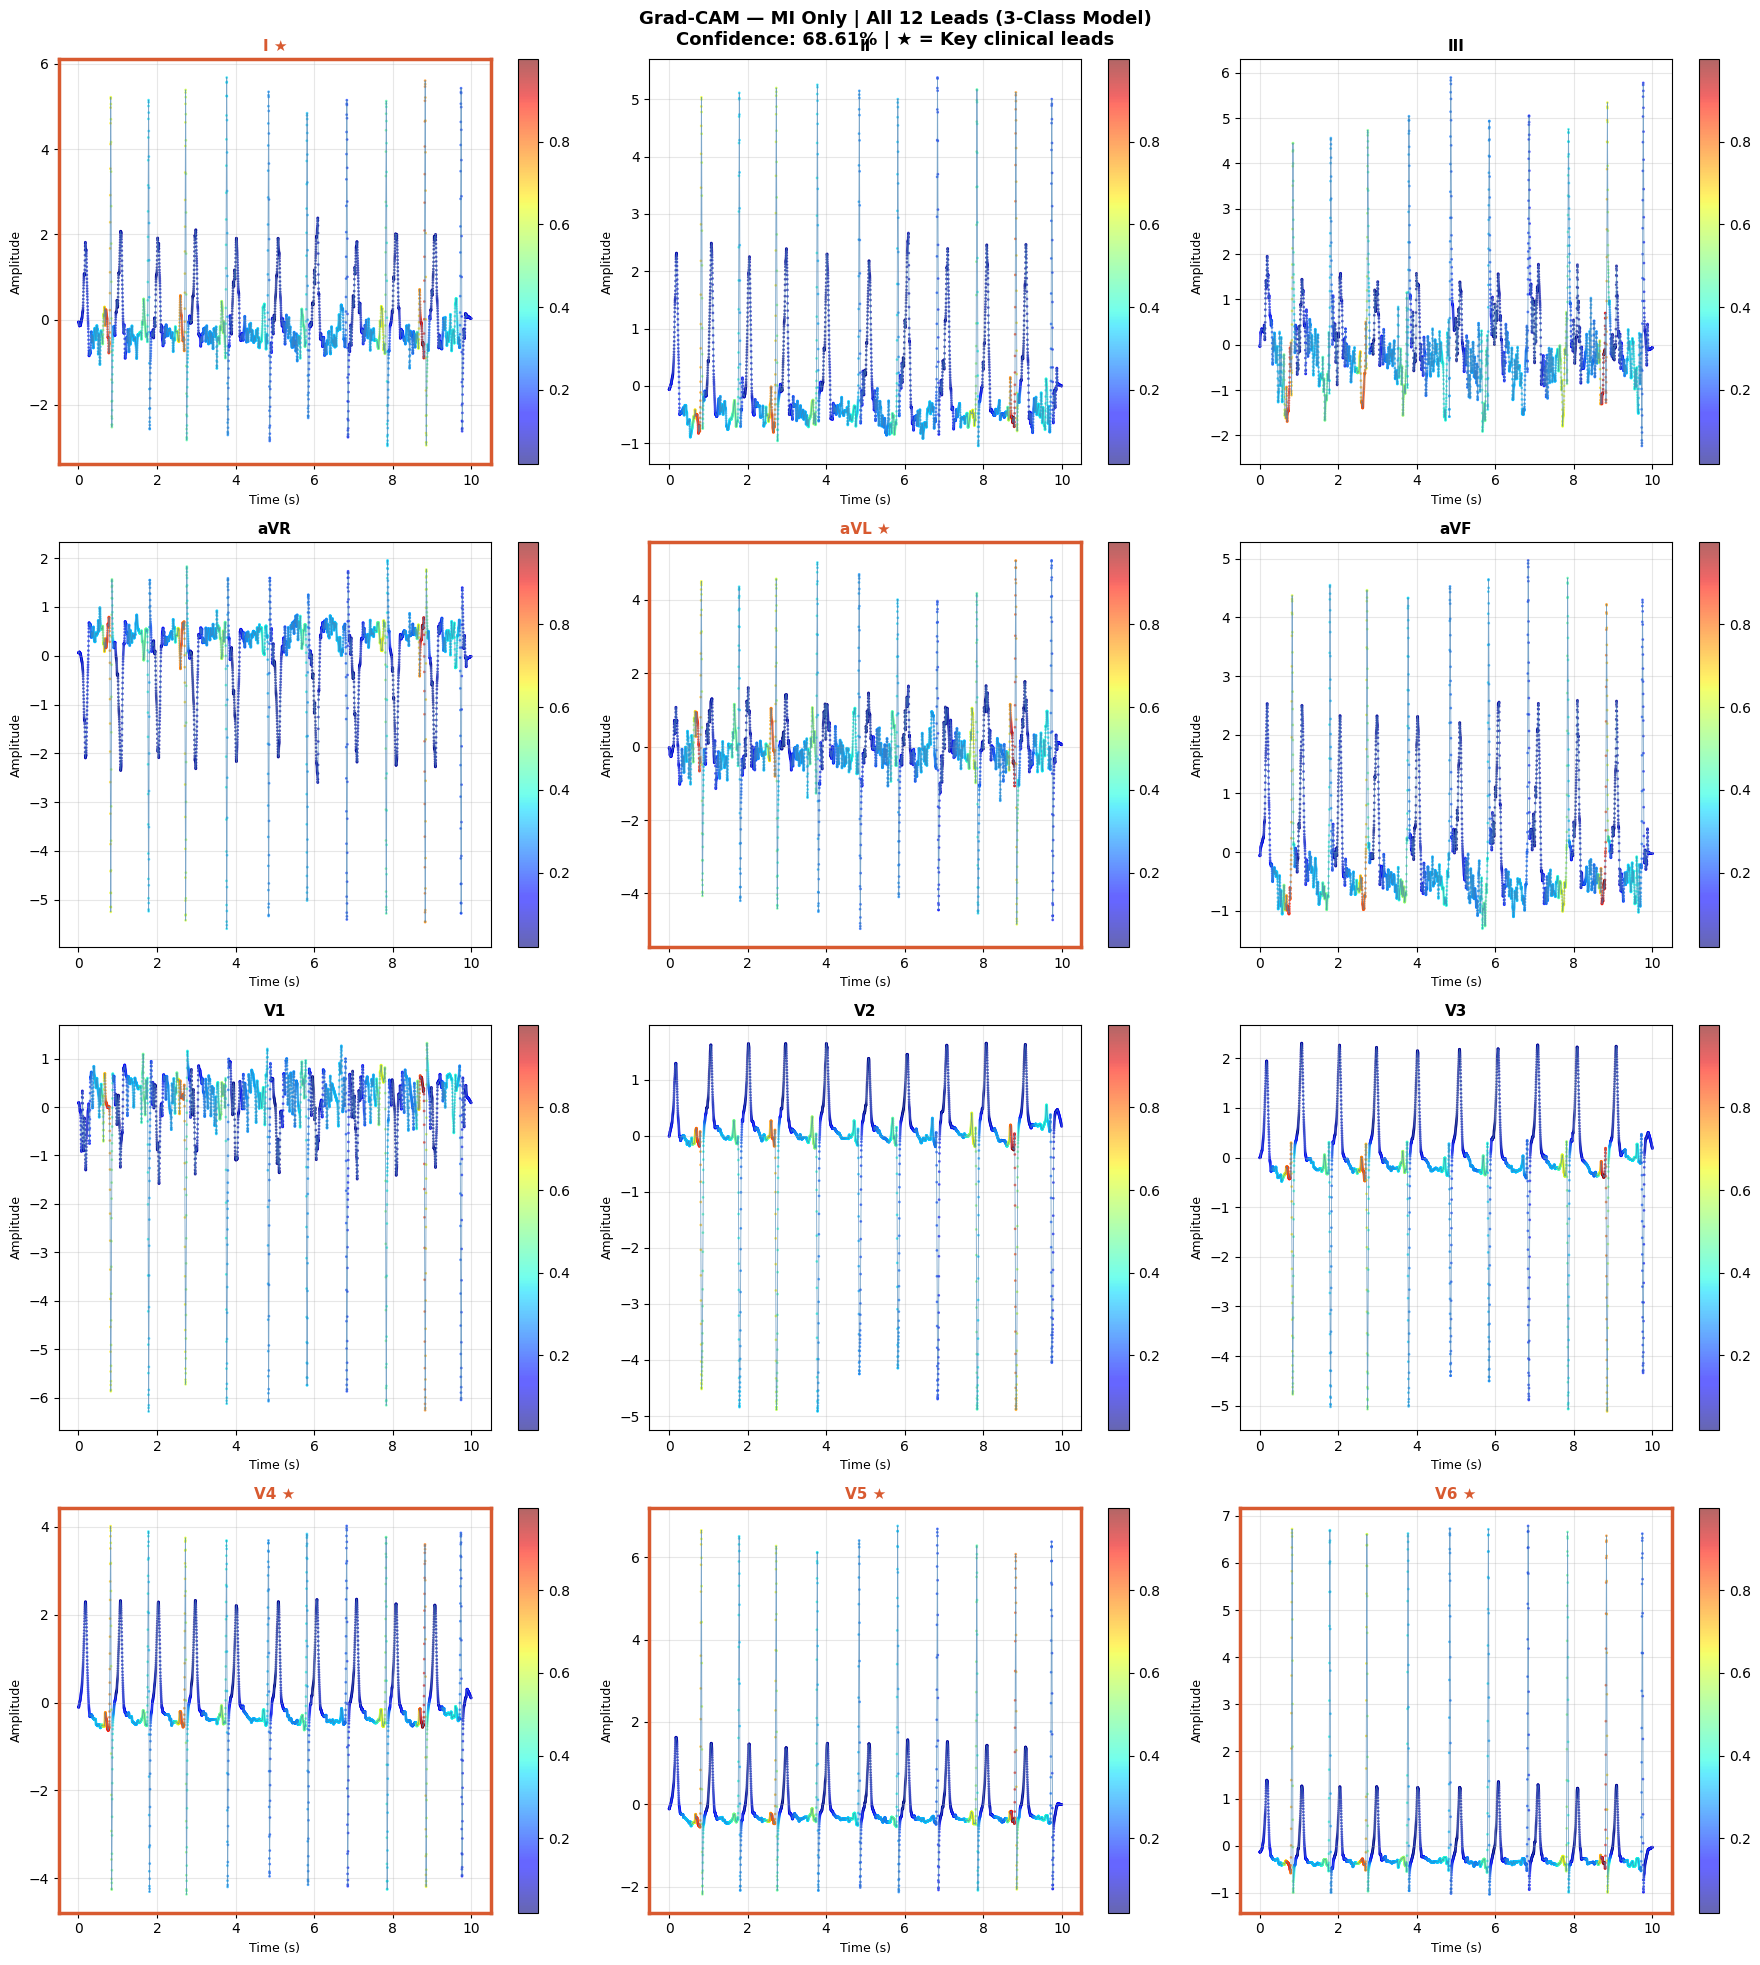

Saved: gradcam_mi_only_12leads.png


In [29]:
def plot_12_leads(ecg, hup, confidence, title, color, key_leads, filename):
    fig, axes = plt.subplots(4, 3, figsize=(18, 20))
    axes_flat = axes.flatten()
    for lead_i, lead_name in enumerate(LEAD_NAMES):
        signal = ecg[:, lead_i]
        ax     = axes_flat[lead_i]
        ax.plot(time_axis, signal, color=color, linewidth=0.6, alpha=0.7)
        sc = ax.scatter(time_axis, signal, c=hup, cmap='jet', s=1, alpha=0.6)
        plt.colorbar(sc, ax=ax)
        ax.set_ylabel('Amplitude', fontsize=9)
        ax.set_xlabel('Time (s)', fontsize=9)
        ax.grid(alpha=0.3)
        if lead_name in key_leads:
            for spine in ax.spines.values():
                spine.set_color('#D85A30')
                spine.set_linewidth(2.5)
            ax.set_title(f'{lead_name} ★', fontsize=11,
                         fontweight='bold', color='#D85A30')
        else:
            ax.set_title(f'{lead_name}', fontsize=11, fontweight='bold')
    plt.suptitle(f'{title}\nConfidence: {confidence:.2%} | ★ = Key clinical leads',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{filename}', dpi=150)
    plt.show()
    print(f"Saved: {filename}")

plot_12_leads(
    ecg=ecg_mi, hup=hup_mi, confidence=conf_mi,
    title='Grad-CAM — MI Only | All 12 Leads (3-Class Model)',
    color='steelblue',
    key_leads=['I', 'aVL', 'V4', 'V5', 'V6'],
    filename='gradcam_mi_only_12leads.png'
)

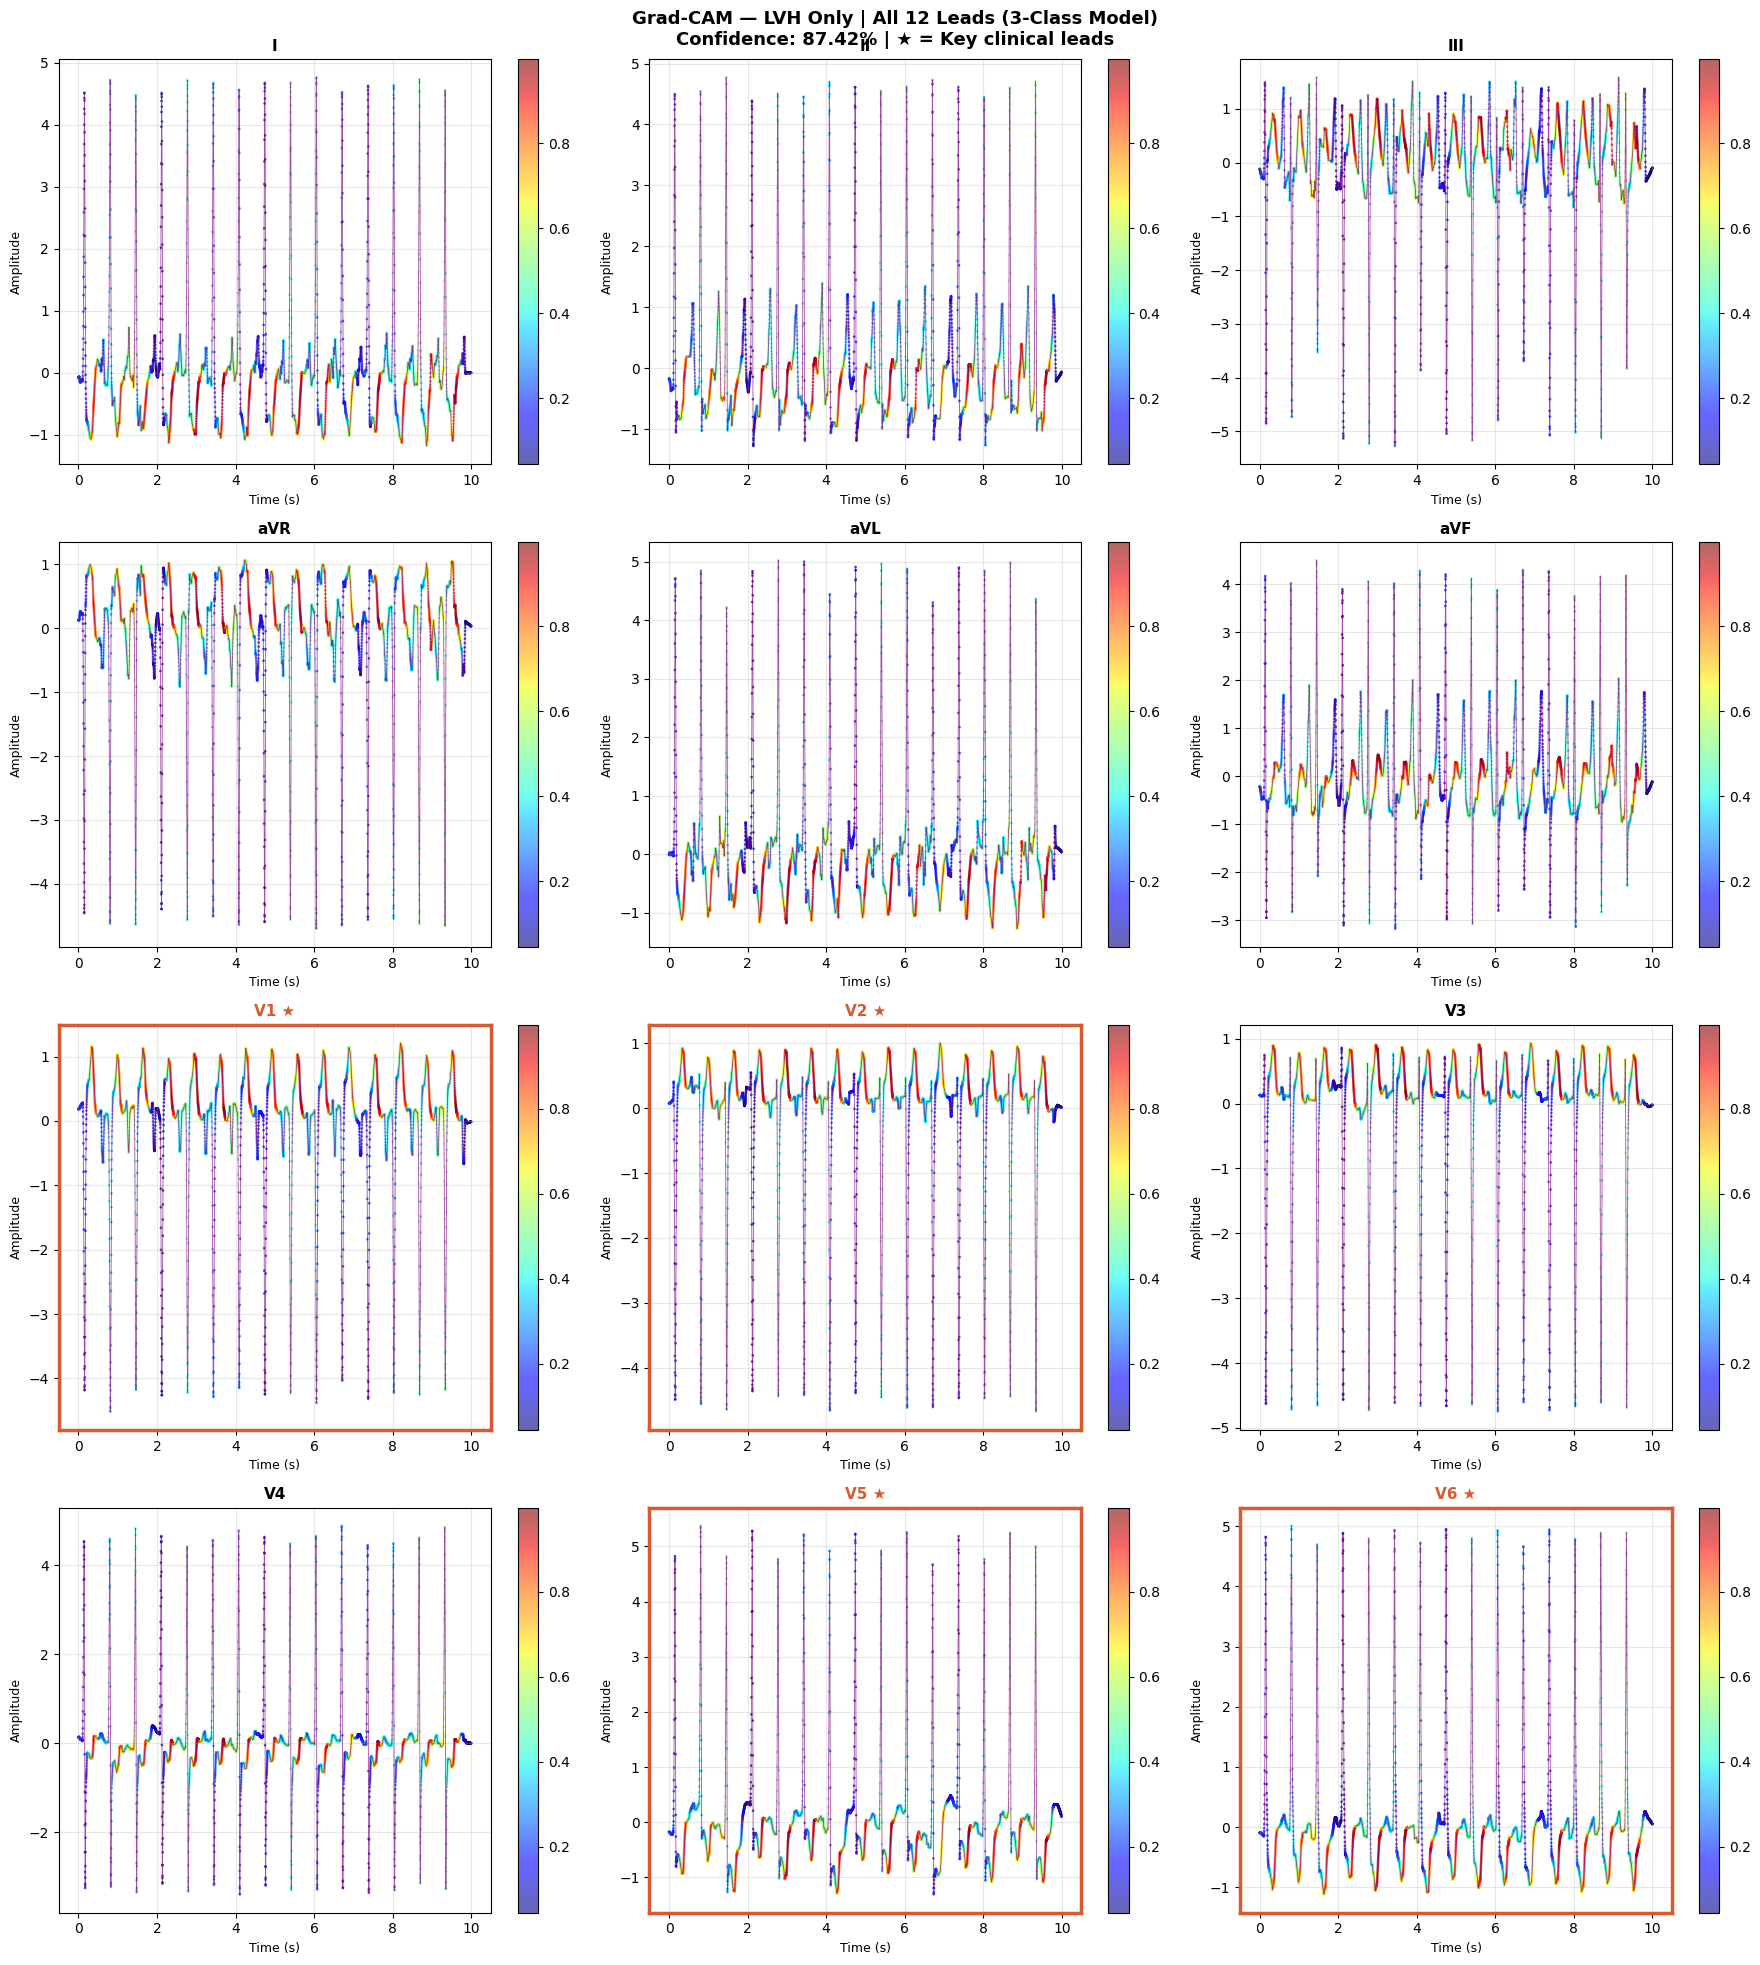

Saved: gradcam_lvh_only_12leads.png


In [30]:
plot_12_leads(
    ecg=ecg_lvh, hup=hup_lvh, confidence=conf_lvh,
    title='Grad-CAM — LVH Only | All 12 Leads (3-Class Model)',
    color='purple',
    key_leads=['V1', 'V2', 'V5', 'V6'],
    filename='gradcam_lvh_only_12leads.png'
)

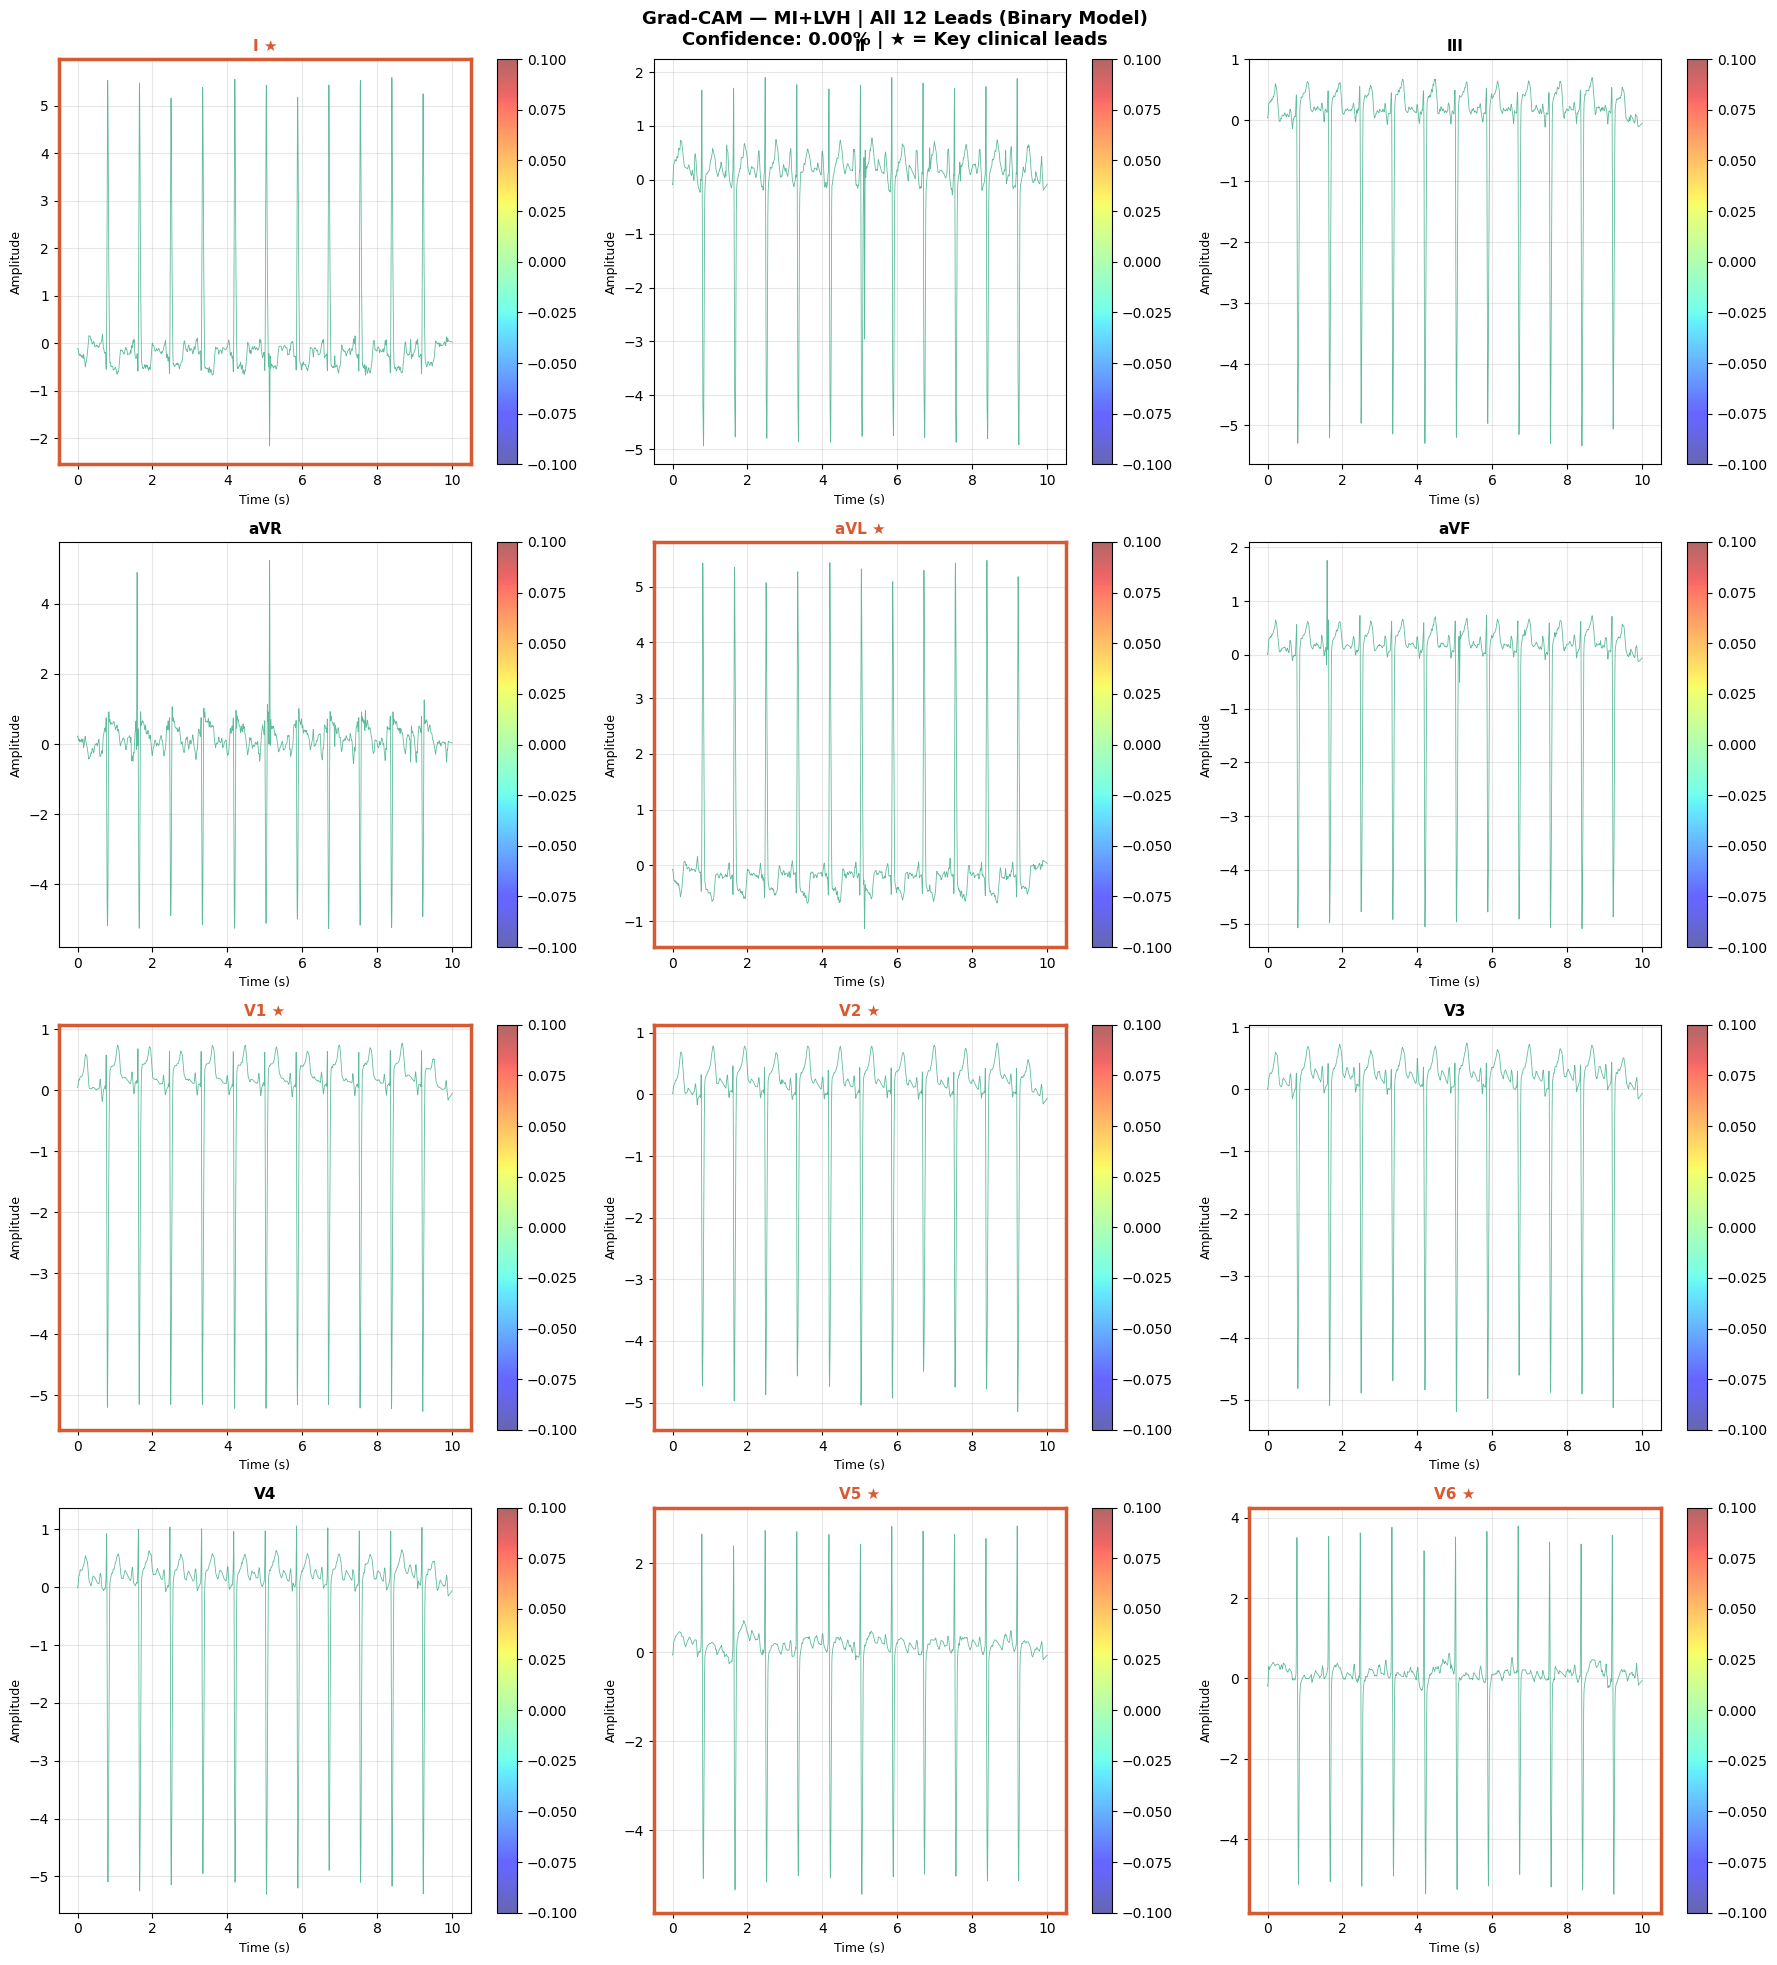

Saved: gradcam_mi_lvh_12leads.png


In [31]:
plot_12_leads(
    ecg=ecg_bin, hup=hup_bin, confidence=conf_bin,
    title='Grad-CAM — MI+LVH | All 12 Leads (Binary Model)',
    color='#1D9E75',
    key_leads=['I', 'aVL', 'V1', 'V2', 'V5', 'V6'],
    filename='gradcam_mi_lvh_12leads.png'
)

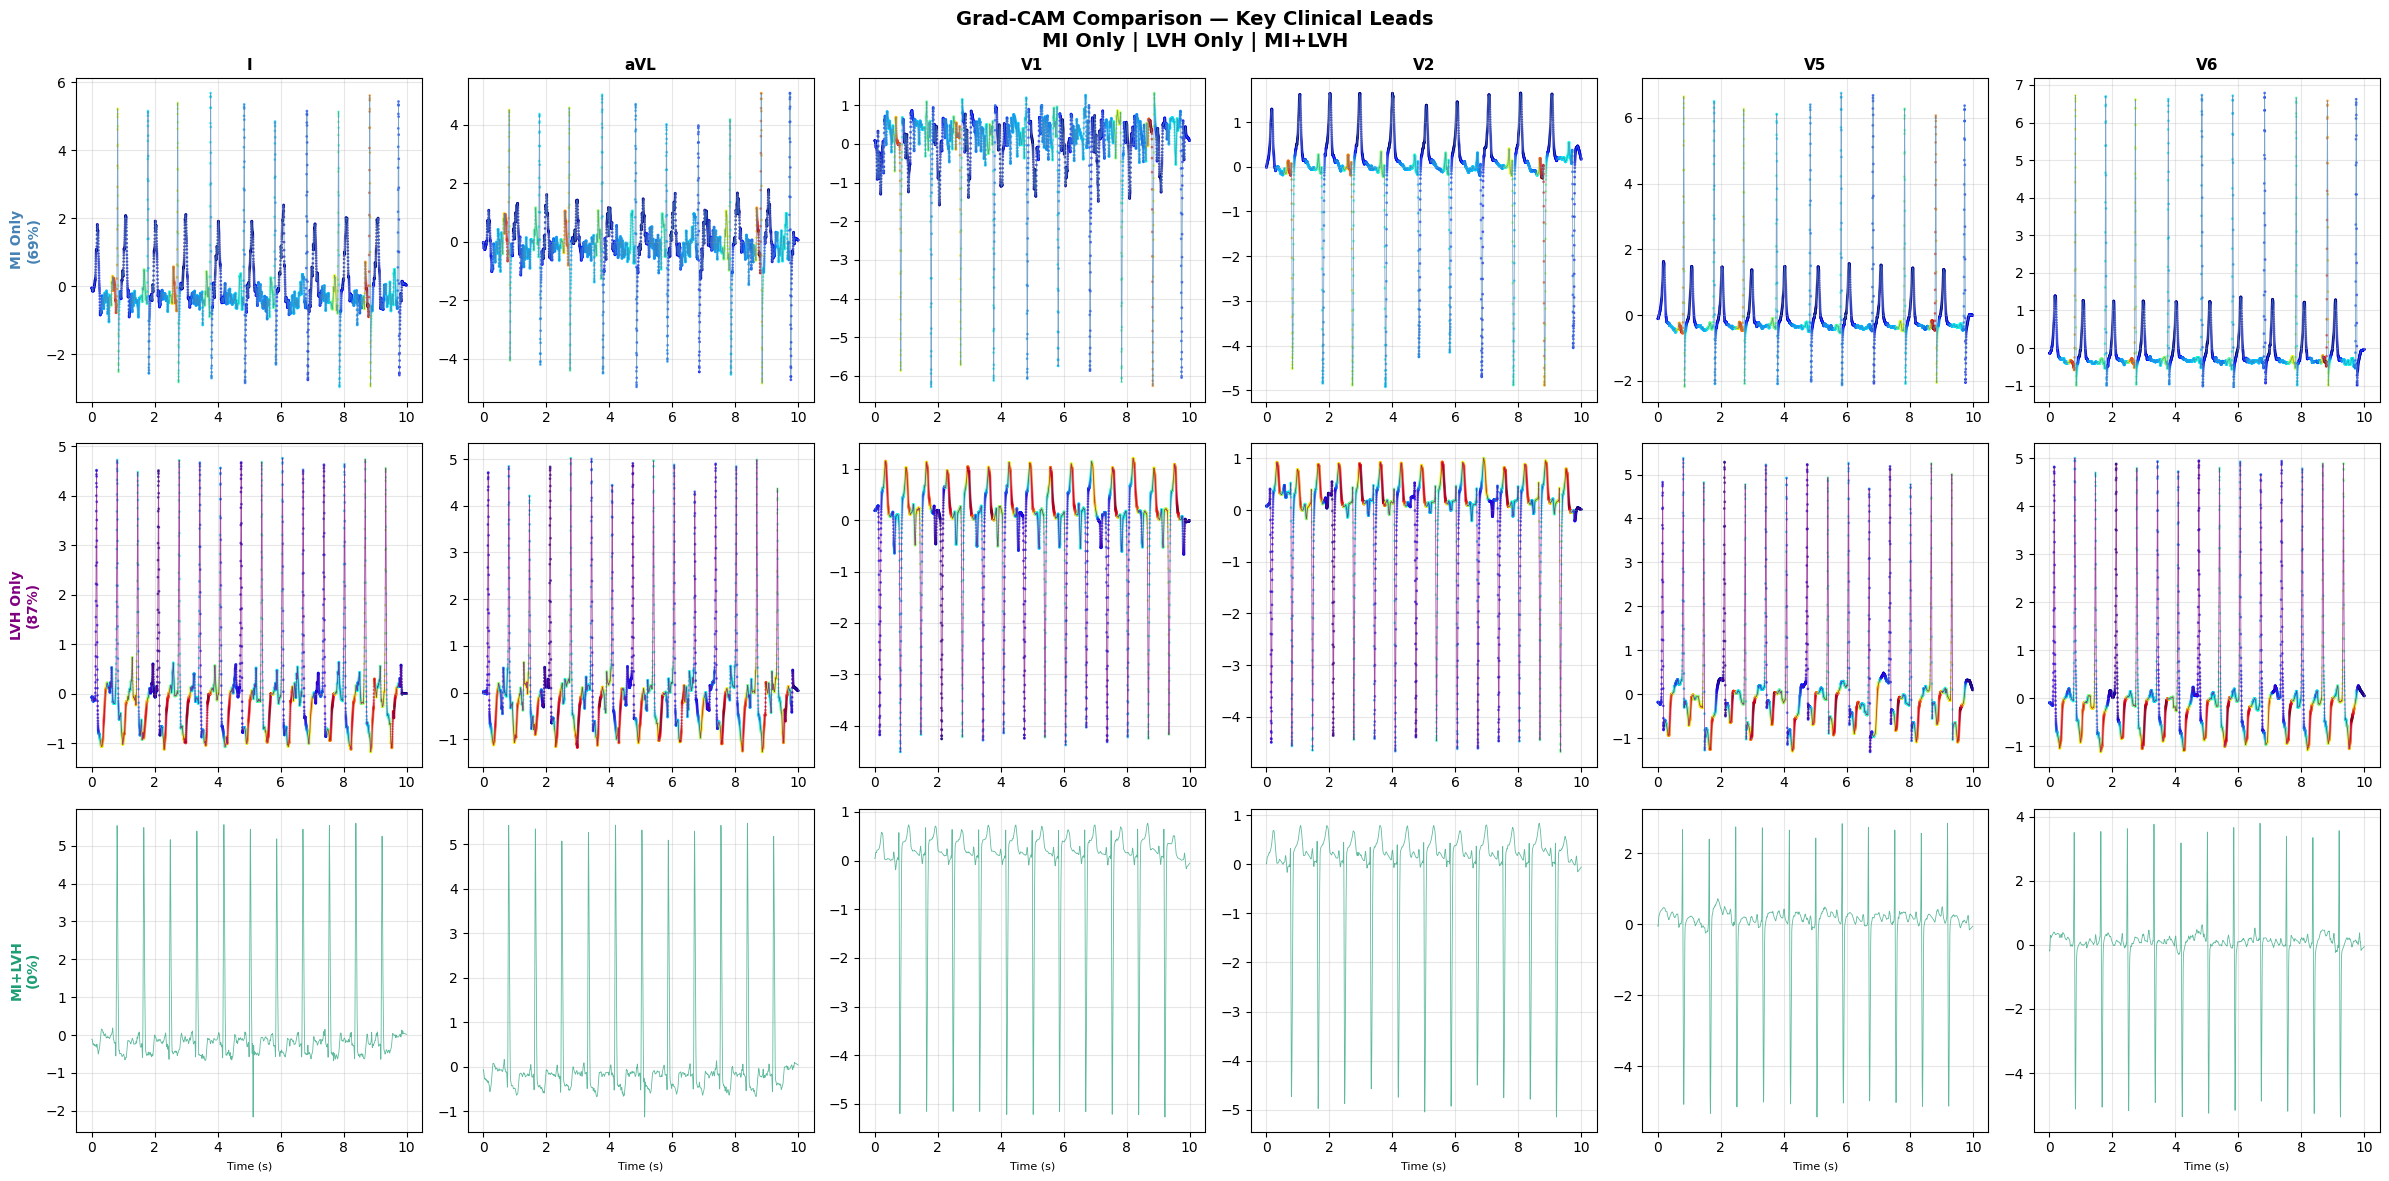

Saved: gradcam_comparison_key_leads.png


In [32]:
key_leads_all = ['I', 'aVL', 'V1', 'V2', 'V5', 'V6']
configs = [
    (ecg_mi,  hup_mi,  conf_mi,  'MI Only',  'steelblue'),
    (ecg_lvh, hup_lvh, conf_lvh, 'LVH Only', 'purple'),
    (ecg_bin, hup_bin, conf_bin, 'MI+LVH',   '#1D9E75'),
]

fig, axes = plt.subplots(3, 6, figsize=(24, 12))

for row, (ecg, hup, conf, label, color) in enumerate(configs):
    for col, lead_name in enumerate(key_leads_all):
        lead_i = LEAD_IDX[lead_name]
        signal = ecg[:, lead_i]
        ax     = axes[row, col]
        ax.plot(time_axis, signal, color=color, linewidth=0.6, alpha=0.7)
        sc = ax.scatter(time_axis, signal, c=hup, cmap='jet', s=1, alpha=0.6)
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(f'{lead_name}', fontsize=11, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{label}\n({conf:.0%})', fontsize=10,
                          fontweight='bold', color=color)
        if row == 2:
            ax.set_xlabel('Time (s)', fontsize=8)

plt.suptitle(
    'Grad-CAM Comparison — Key Clinical Leads\n'
    'MI Only | LVH Only | MI+LVH',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_comparison_key_leads.png', dpi=150)
plt.show()
print("Saved: gradcam_comparison_key_leads.png")

Computing SHAP for 3-class model (takes ~5 min)...


  0%|          | 0/50 [00:00<?, ?it/s]

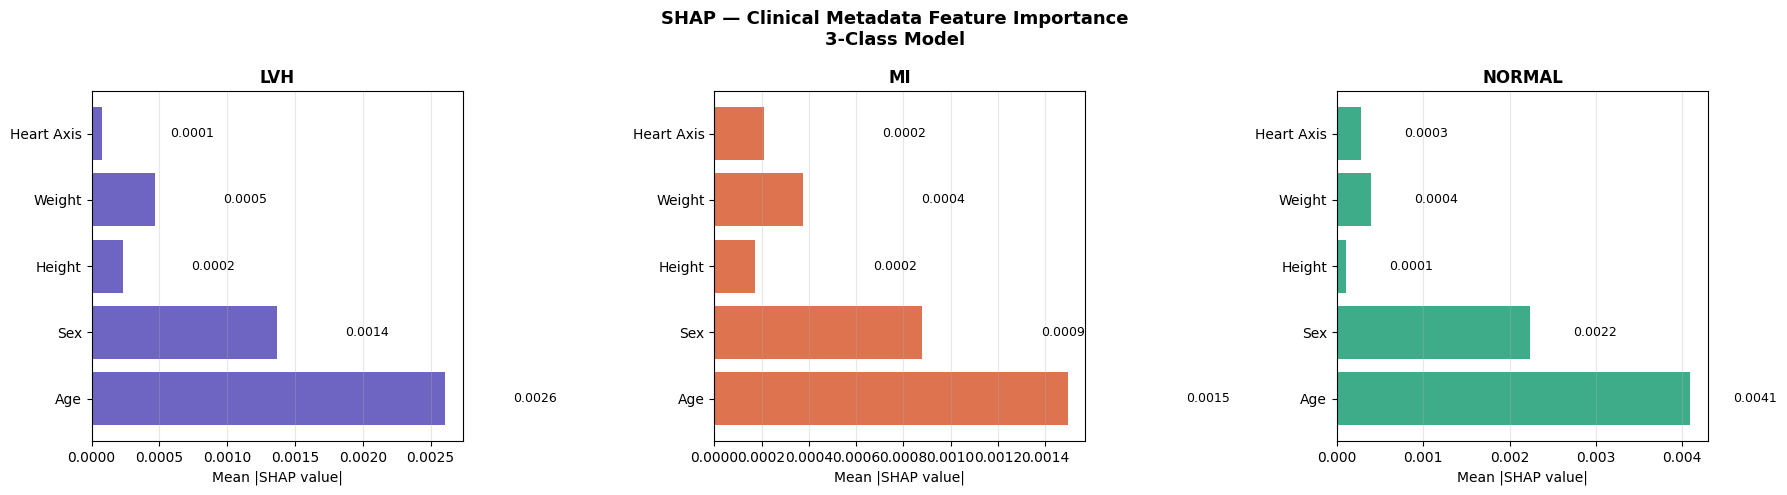

Saved: shap_3class.png


In [33]:
print("Computing SHAP for 3-class model (takes ~5 min)...")
feature_names = ['Age', 'Sex', 'Height', 'Weight', 'Heart Axis']

def predict_3class(meta_samples):
    n = len(meta_samples)
    ecg_rep = np.repeat(X_test_3[:1], n, axis=0)
    return model_fusion_3.predict(
        [ecg_rep, meta_samples.astype(np.float32)],
        batch_size=32, verbose=0
    )

explainer_3   = shap.KernelExplainer(predict_3class, meta_train_3[:30])
shap_values_3 = explainer_3.shap_values(meta_test_3[:50], nsamples=100)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_3  = ['#534AB7', '#D85A30', '#1D9E75']

for cls_idx, cls_name in enumerate(CLASS_NAMES_3):
    ax = axes[cls_idx]
    sv = shap_values_3[cls_idx] if isinstance(shap_values_3, list) \
         else shap_values_3[:, :, cls_idx]
    mean_shap = np.abs(sv).mean(axis=0)
    bars = ax.barh(feature_names, mean_shap,
                   color=colors_3[cls_idx], alpha=0.85)
    ax.set_title(f'{cls_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, mean_shap):
        ax.text(bar.get_width() + 0.0005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('SHAP — Clinical Metadata Feature Importance\n3-Class Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_3class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_3class.png")

In [ ]:
print("Computing SHAP for binary model (takes ~5 min)...")

def predict_binary(meta_samples):
    n = len(meta_samples)
    ecg_rep = np.repeat(X_test_b[:1], n, axis=0)
    return model_fusion_b.predict(
        [ecg_rep, meta_samples.astype(np.float32)],
        batch_size=32, verbose=0
    )

explainer_b   = shap.KernelExplainer(predict_binary, meta_train_bin[:30])
shap_values_b = explainer_b.shap_values(meta_test_bin[:50], nsamples=100)

feature_names = ['Age', 'Sex', 'Height', 'Weight', 'Heart Axis']
colors_b      = ['#D85A30', '#1D9E75']

for cls_idx, cls_name in enumerate(CLASS_NAMES_BIN):
    # ONE figure per class — full size
    fig, ax = plt.subplots(figsize=(16, 10))

    if isinstance(shap_values_b, list):
        sv = shap_values_b[cls_idx]
    else:
        sv = shap_values_b
    mean_shap = np.abs(sv).mean(axis=0)
    if mean_shap.ndim > 1:
        mean_shap = mean_shap[:, 0]

    bars = ax.barh(feature_names, mean_shap,
                   color=colors_b[cls_idx], alpha=0.85,
                   height=0.4)

    ax.set_title(f'SHAP Feature Importance — {cls_name}',
                 fontsize=22, fontweight='bold', pad=20)
    ax.set_xlabel('Mean |SHAP value|', fontsize=16)
    ax.tick_params(axis='both', labelsize=15)
    ax.grid(alpha=0.3, axis='x')

    max_val = max(mean_shap)
    for bar, val in zip(bars, mean_shap):
        ax.text(bar.get_width() + max_val * 0.02,
                bar.get_y() + bar.get_height()/2,
                f'{val:.5f}', va='center',
                fontsize=15, fontweight='bold')

    ax.set_xlim(0, max_val * 1.3)
    plt.tight_layout(pad=3.0)
    fname = f'/kaggle/working/shap_binary_{cls_name}.png'
    plt.savefig(fname, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {fname}")